In [4]:
# -- coding: utf-8 --
"""jetracce-train.ipynb"""

# Install required version of TensorFlow
# !pip install tensorflow==1.15

import tensorflow as tf
from tensorflow import keras as K
import pennylane as qml

# Timer
from timeit import default_timer as timer
from datetime import timedelta

# for data
import pandas as pd
import numpy as np
from os import listdir
import os
from matplotlib import pyplot as plt
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from PIL import Image


# Get processed data
PREPROCESS = True
folder = "C:/Users/Shashank Kadarla/Downloads/l_renamed/train_renamed"
processFolder = "C:/Users/Shashank Kadarla/Downloads/l_renamed/processed"

directs = listdir(folder)
print(directs)
images = []
labels = []
i = 0
for f in directs:
    try:
        img = Image.open(os.path.join(folder, f))
        img = img.convert('L')  # Convert to grayscale
        img = img.resize((640, 640))  # Resize the image to the required size
        img = np.array(img)
        scale_percent = 20 # percent of original size
        width = int(img.shape[1] * scale_percent / 100)
        height = int(img.shape[0] * scale_percent / 100)
        dim = (width, height)

        # resize image
        resized = cv2.resize(img, dim, interpolation = cv2.INTER_AREA)
        NorImages = resized/255
        images.append(NorImages)
        print(f"File {f} processed")
        i += 1
    except Exception as e:
        print(f"Error processing file {f}: {e}")
        continue

# Convert to numpy arrays
npimages = np.asarray(images)
print(npimages.shape)

# Load the CSV file for labels
df = pd.read_csv("C:/Users/Shashank Kadarla/Downloads/class_lables copy.csv")
df = df.drop(columns=['filename'])

# Encode each class to numeric values (1, 2, 3, 4)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
encoded_df = df.apply(label_encoder.fit_transform)
result_list = encoded_df.values.tolist()

label_list = []
for i in range(len(result_list)):
    if result_list[i][0] == 1:
        label_list.append(1)
    elif result_list[i][1] == 1:
        label_list.append(2)
    elif result_list[i][2] == 1:
        label_list.append(3)
    elif result_list[i][3] == 1:
        label_list.append(4)
    else:
        label_list.append(0)

nplabels = np.asarray(label_list)
print(nplabels.shape)


['Image_1.png', 'Image_10.png', 'Image_100.png', 'Image_1000.png', 'Image_1001.png', 'Image_1002.png', 'Image_1003.png', 'Image_1004.png', 'Image_1005.png', 'Image_1006.png', 'Image_1007.png', 'Image_1008.png', 'Image_1009.png', 'Image_101.png', 'Image_1010.png', 'Image_1011.png', 'Image_1012.png', 'Image_1013.png', 'Image_1014.png', 'Image_1015.png', 'Image_1016.png', 'Image_1017.png', 'Image_1018.png', 'Image_1019.png', 'Image_102.png', 'Image_1020.png', 'Image_1021.png', 'Image_1022.png', 'Image_1023.png', 'Image_1024.png', 'Image_1025.png', 'Image_1026.png', 'Image_1027.png', 'Image_1028.png', 'Image_1029.png', 'Image_103.png', 'Image_1030.png', 'Image_1031.png', 'Image_1032.png', 'Image_1033.png', 'Image_1034.png', 'Image_1035.png', 'Image_1036.png', 'Image_1037.png', 'Image_1038.png', 'Image_1039.png', 'Image_104.png', 'Image_1040.png', 'Image_1041.png', 'Image_1042.png', 'Image_1043.png', 'Image_1044.png', 'Image_1045.png', 'Image_1046.png', 'Image_1047.png', 'Image_1048.png', '

In [6]:
wires=4

dev4 = qml.device("lightning.qubit", wires=wires)  # define the simulator
@qml.qnode(dev4)
def CONVCircuit(phi, wires, i=0):
    """
    quantum convolution Node
    """
    # parameter
    theta = np.pi / 4

    qml.RX(phi[0] * np.pi, wires=0)
    qml.RX(phi[1] * np.pi, wires=1)
    qml.RX(phi[2] * np.pi, wires=2)
    qml.RX(phi[3] * np.pi, wires=3)

    qml.CRZ(theta, wires=[1, 0])
    qml.CRZ(theta, wires=[3, 2])
    qml.CRX(theta, wires=[1, 0])
    qml.CRX(theta, wires=[3, 2])
    qml.CRZ(theta, wires=[2, 0])
    qml.CRX(theta, wires=[2, 0])

    # Expectation value
    measurement = qml.expval(qml.PauliZ(wires=0))

    return measurement


def quanv(X):
    """
    quantum convolutional layer
    """

    #H, W, CH = X.shape
    H, W = X.shape
    step = 2
    out = np.zeros(((H//step), (W//step)))
    #progress = 0
    for i in range(0, W, step):
        for j in range(0, H, step):
            # get 2x2 pixels and make them 1D array
            phi = X[i:i+2, j:j+2].flatten()
            # Get Measurement
            measurement = CONVCircuit(phi, len(phi))
            out[i//step, j//step] = measurement

    return out

# Train, validation, test split
X_train, X_test, y_train, y_test = train_test_split(npimages, nplabels, test_size=0.3, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

print(X_train.shape, X_valid.shape, X_test.shape, y_train.shape, y_valid.shape, y_test.shape)

n_train = X_train.shape[0]
n_test = X_test.shape[0]
n_valid = X_valid.shape[0]

(4200, 128, 128) (900, 128, 128) (900, 128, 128) (4200,) (900,) (900,)


In [ ]:
 #no need to run this, if u have the quantum processed images
if PREPROCESS == True:
    q_train_images = []
    print("Quantum pre-processing of train images:")
    for idx, img in enumerate(X_train):
        print("{}/{}        ".format(idx + 1, n_train), end="\r")
        q_train_images.append(quanv(img))
    q_train_images = np.asarray(q_train_images)

    q_test_images = []
    print("\nQuantum pre-processing of test images:")
    for idx, img in enumerate(X_test):
        print("{}/{}        ".format(idx + 1, n_test), end="\r")
        q_test_images.append(quanv(img))
    q_test_images = np.asarray(q_test_images)

    q_valid_images = []
    print("\nQuantum pre-processing of validation images:")
    for idx, img in enumerate(X_valid):
        print("{}/{}        ".format(idx + 1, n_valid), end="\r")
        q_valid_images.append(quanv(img))
    q_valid_images = np.asarray(q_valid_images)    

    # Save pre-processed images
    np.save(processFolder + "q_train_images.npy", q_train_images)
    np.save(processFolder + "q_test_images.npy", q_test_images)
    np.save(processFolder + "q_valid_images.npy", q_valid_images)


In [9]:
# Load preprocessed images
q_train_images = np.load("C:/Users/Shashank Kadarla/Downloads/l_renamed/processedl_model_train_images.npy")
q_valid_images = np.load("C:/Users/Shashank Kadarla/Downloads/l_renamed/processedl_model_valid_images.npy")
q_test_images = np.load("C:/Users/Shashank Kadarla/Downloads/l_renamed/processedl_model_test_images.npy")
# Print shape to verify the loaded data
print(q_train_images.shape, q_test_images.shape, q_valid_images.shape)

(4200, 64, 64) (900, 64, 64) (900, 64, 64)


In [21]:
def Model():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Flatten(),  # Flatten the input
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(5, activation="softmax")  # Output layer for 5 classes
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

q_model = Model()

# Implement early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=3,          # Stop after 3 epochs with no improvement
    restore_best_weights=True  # Restore the model with the best weights
)

# Train the model with early stopping
q_history = q_model.fit(
    q_train_images, y_train,
    validation_data=(q_valid_images, y_valid),
    batch_size=16,
    epochs=20,
    verbose=2,
    callbacks=[early_stopping]  # Add early stopping callback
)
# Ensure the directory exists
save_dir = 'QModel_saved'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Save the model
q_model.save(os.path.join(save_dir, 'QModel_saved.keras'))


Epoch 1/20
263/263 - 4s - 17ms/step - accuracy: 0.6143 - loss: 1.0299 - val_accuracy: 0.6922 - val_loss: 0.6064
Epoch 2/20
263/263 - 2s - 8ms/step - accuracy: 0.7098 - loss: 0.6768 - val_accuracy: 0.7611 - val_loss: 0.5147
Epoch 3/20
263/263 - 2s - 8ms/step - accuracy: 0.7452 - loss: 0.5863 - val_accuracy: 0.7944 - val_loss: 0.4461
Epoch 4/20
263/263 - 2s - 8ms/step - accuracy: 0.7752 - loss: 0.5138 - val_accuracy: 0.8289 - val_loss: 0.4177
Epoch 5/20
263/263 - 2s - 8ms/step - accuracy: 0.7850 - loss: 0.4922 - val_accuracy: 0.8267 - val_loss: 0.4161
Epoch 6/20
263/263 - 2s - 8ms/step - accuracy: 0.7924 - loss: 0.4601 - val_accuracy: 0.8211 - val_loss: 0.3942
Epoch 7/20
263/263 - 2s - 8ms/step - accuracy: 0.8050 - loss: 0.4440 - val_accuracy: 0.8300 - val_loss: 0.3856
Epoch 8/20
263/263 - 2s - 8ms/step - accuracy: 0.8136 - loss: 0.4266 - val_accuracy: 0.8344 - val_loss: 0.3839
Epoch 9/20
263/263 - 2s - 8ms/step - accuracy: 0.8205 - loss: 0.4171 - val_accuracy: 0.8411 - val_loss: 0.3622


In [23]:
q_model.save('QModel_saved.keras')  # Save as a single .keras file
q_model = K.models.load_model('QModel_saved.keras')


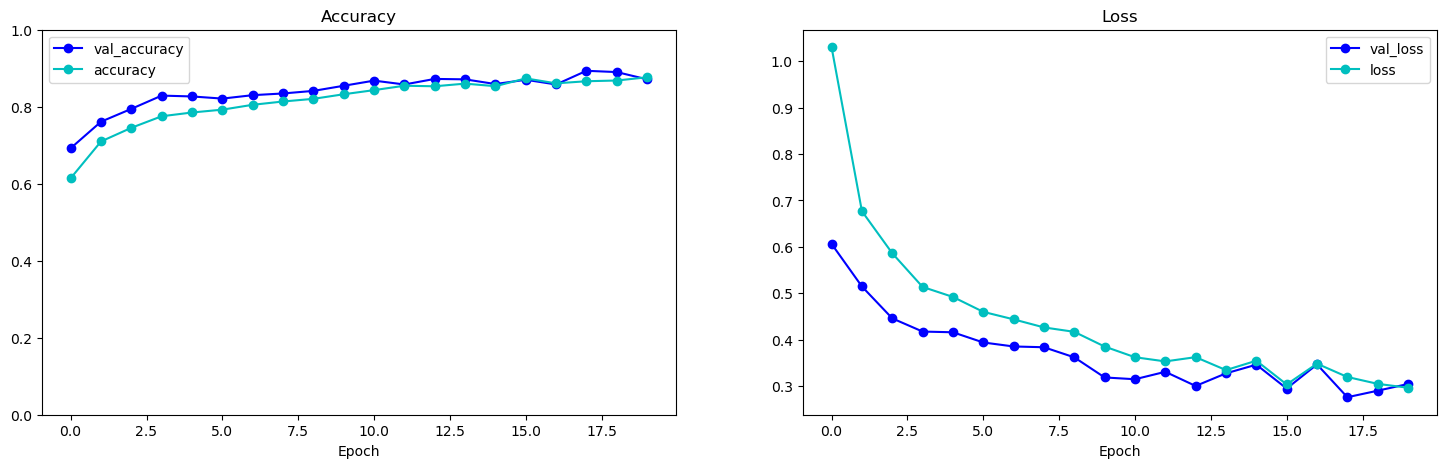

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           1       0.95      0.84      0.89       232
           2       0.95      0.94      0.94       223
           3       0.82      0.91      0.86       235
           4       0.83      0.84      0.84       210

    accuracy                           0.88       900
   macro avg       0.89      0.88      0.88       900
weighted avg       0.89      0.88      0.88       900

Normalized confusion matrix


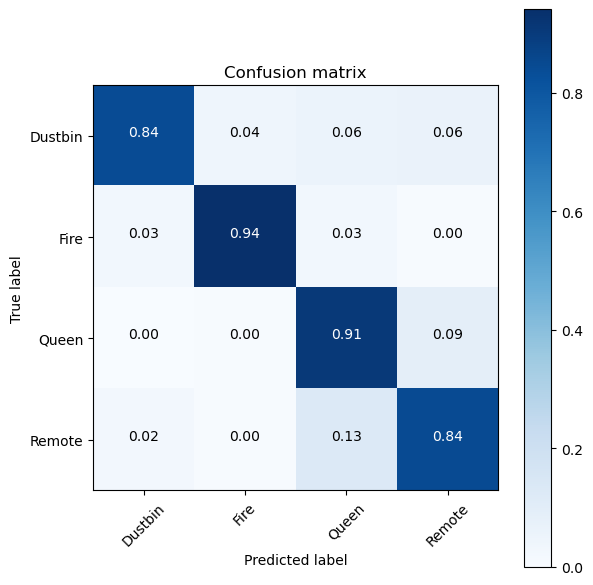

In [55]:
# Plot accuracy and loss
import itertools  # Add this line

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
ax1.plot(q_history.history["val_accuracy"], "-ob", label="val_accuracy")
ax1.plot(q_history.history["accuracy"], "-oc", label="accuracy")
ax1.set_ylim([0, 1])
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(q_history.history["val_loss"], "-ob", label="val_loss")
ax2.plot(q_history.history["loss"], "-oc", label="loss")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.legend()
plt.show()

# Load the model for prediction
q_model = K.models.load_model('QModel_saved.keras')

# Predict on the test set
yhat = q_model.predict(q_test_images)
yhat = yhat.argmax(axis=1)

# Classification report
print(classification_report(y_test, yhat))

# Plot confusion matrix
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Create confusion matrix
cnf_matrix = tf.math.confusion_matrix(y_test, yhat)
plt.figure(figsize=(6, 6))
plot_confusion_matrix(np.array(cnf_matrix[1:, 1:]), classes=['Dustbin', 'Fire', 'Queen', 'Remote'], normalize=True, title='Confusion matrix')
plt.show()

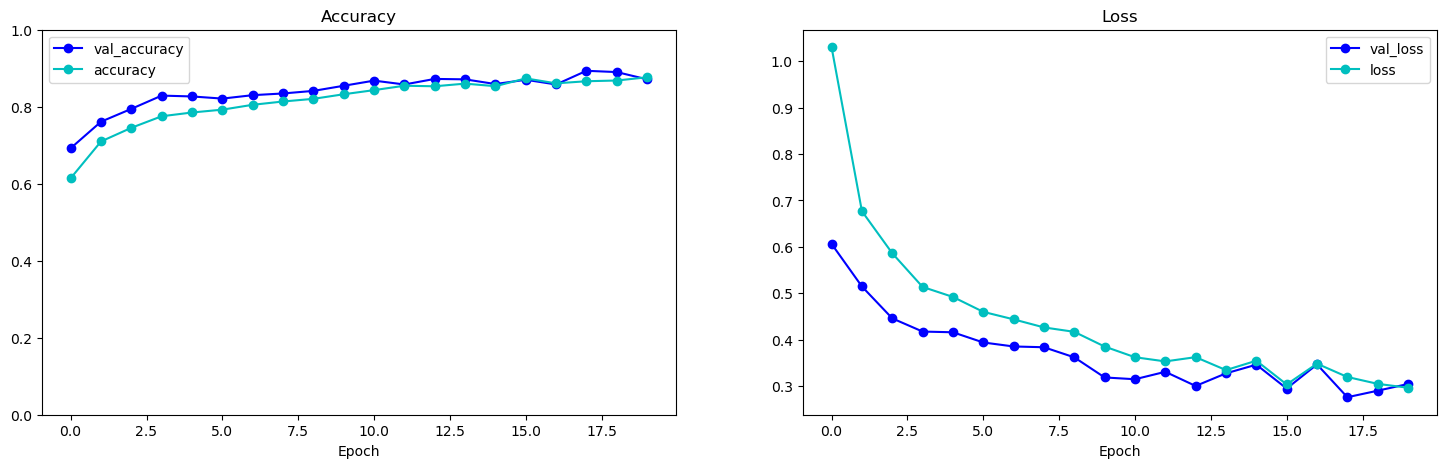

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

           1       0.98      0.90      0.94       232
           2       0.98      0.99      0.98       228
           3       0.78      0.91      0.84       227
           4       0.85      0.77      0.81       213

    accuracy                           0.89       900
   macro avg       0.90      0.89      0.89       900
weighted avg       0.90      0.89      0.89       900

Normalized confusion matrix


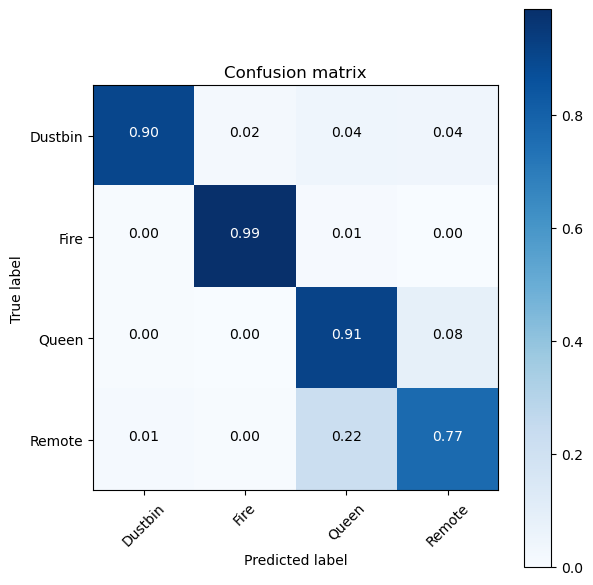

In [53]:
# Plot accuracy and loss
import itertools  # Add this line

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
ax1.plot(q_history.history["val_accuracy"], "-ob", label="val_accuracy")
ax1.plot(q_history.history["accuracy"], "-oc", label="accuracy")
ax1.set_ylim([0, 1])
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(q_history.history["val_loss"], "-ob", label="val_loss")
ax2.plot(q_history.history["loss"], "-oc", label="loss")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.legend()
plt.show()

# Load the model for prediction
q_model = K.models.load_model('QModel_saved.keras')

# Predict on the test set
yhat = q_model.predict(q_valid_images)
yhat = yhat.argmax(axis=1)

# Classification report
print(classification_report(y_valid, yhat))

# Plot confusion matrix
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Create confusion matrix
cnf_matrix = tf.math.confusion_matrix(y_valid, yhat)
plt.figure(figsize=(6, 6))
plot_confusion_matrix(np.array(cnf_matrix[1:, 1:]),classes=['Dustbin', 'Fire', 'Queen', 'Remote'], normalize=True, title='Confusion matrix')
plt.show()

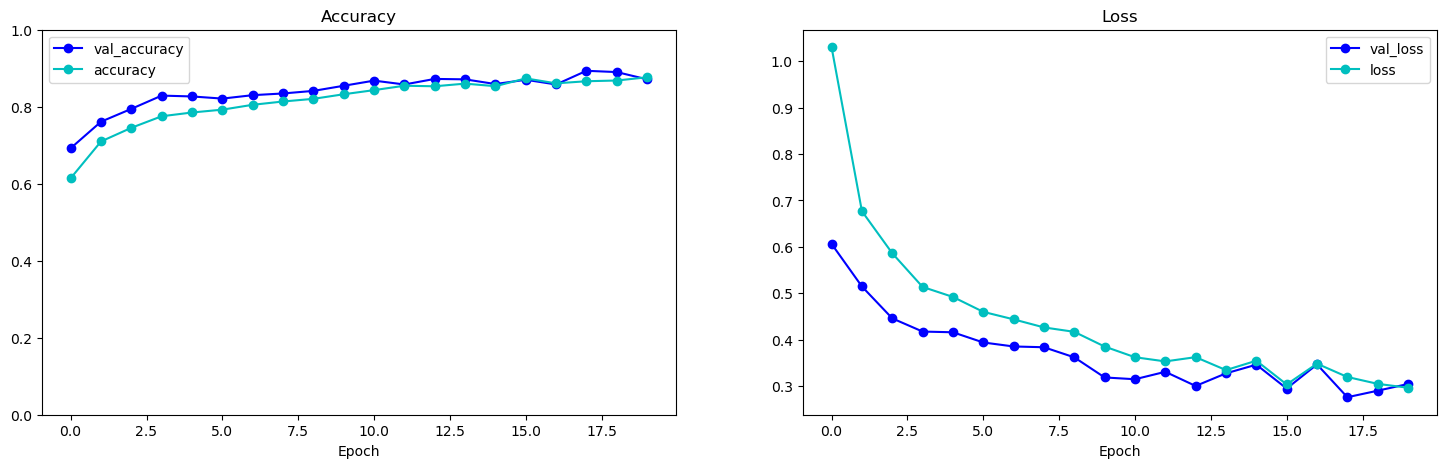

132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           1       0.99      0.94      0.96      1069
           2       1.00      1.00      1.00      1016
           3       0.85      0.95      0.90      1038
           4       0.91      0.86      0.88      1077

    accuracy                           0.93      4200
   macro avg       0.94      0.93      0.93      4200
weighted avg       0.94      0.93      0.93      4200

Normalized confusion matrix


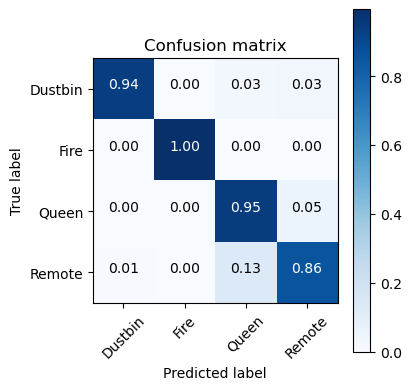

In [61]:
# Plot accuracy and loss
import itertools  # Add this line

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
ax1.plot(q_history.history["val_accuracy"], "-ob", label="val_accuracy")
ax1.plot(q_history.history["accuracy"], "-oc", label="accuracy")
ax1.set_ylim([0, 1])
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(q_history.history["val_loss"], "-ob", label="val_loss")
ax2.plot(q_history.history["loss"], "-oc", label="loss")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.legend()
plt.show()

# Load the model for prediction
q_model = K.models.load_model('QModel_saved.keras')

# Predict on the test set
yhat = q_model.predict(q_train_images)
yhat = yhat.argmax(axis=1)

# Classification report
print(classification_report(y_train, yhat))

# Plot confusion matrix
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Create confusion matrix
cnf_matrix = tf.math.confusion_matrix(y_train, yhat)
plt.figure(figsize=(4, 4))
plot_confusion_matrix(np.array(cnf_matrix[1:, 1:]),classes=['Dustbin', 'Fire', 'Queen', 'Remote'], normalize=True, title='Confusion matrix')
plt.show()